In [ ]:
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**CNN TRAINING PIPELINE FOR CIFAR-10 (NPU-ORIENTED DESIGN)**
===============================================================================

**Mục tiêu:**

    - Huấn luyện mô hình CNN cho bài toán Image Classification (CIFAR-10)
    - Thiết kế kiến trúc phù hợp để triển khai trên NPU tự thiết kế (Verilog)
    - Target FPGA: Terasic DE10-Standard (Cyclone V)

**Đặc điểm thiết kế (Hardware-aware):**

    - Chỉ sử dụng các phép toán cơ bản:
        + Convolution (3x3)
        + ReLU
        + MaxPooling
        + Fully Connected
    - Tránh các layer phức tạp (Dropout, Residual, Attention)
    - Kiến trúc gọn nhẹ, dễ mapping sang phần cứng

**Pipeline:**

    1. Load & preprocess CIFAR-10
    2. Data augmentation (train)
    3. Xây dựng CNN model
    4. Training (AdamW + Cosine LR)
    5. Lưu best model
    6. Evaluate & phân tích kết quả

**Triển khai phần cứng:**

    - Fuse BatchNorm vào Conv
    - Quantize về INT8
    - Export weights → HEX
    - Mapping sang NPU (Verilog)

**LÝ THUYẾT**
===============================================================================

**Batch size:** Số mẫu (ảnh) mà model học trong 1 iteration.

**Iteration:** 1 iteration = 1 batch được xử lý = 1 lần update weight.

**Epoch:** 1 epoch = 1 lần model đi qua toàn bộ dataset

**Toàn bộ dataset không được đưa vào model trong một lần:**

→ Chia dataset thành nhiều batch

→ Mỗi batch có kích thước là batch size

→ Mỗi batch được xử lý trong 1 iteration

→ Sau khi xử lý hết tất cả các batch → hoàn thành 1 epoch

**DATA PREPROCESSING & AUGMENTATION**
===============================================================================
- Chuẩn hóa dữ liệu theo thống kê CIFAR-10
- Tăng đa dạng dữ liệu bằng augmentation (train set)

In [ ]:
# CIFAR-10 normalization stats
cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std = (0.2470, 0.2435, 0.2616)

# Pipeline xử lý dữ liệu cho tập train
transform_train = transforms.Compose(
     # thêm padding xung quanh ảnh gốc, crop ngẫu nhiên 1 vùng 32×32
    [transforms.RandomCrop(32, padding=4),
     # lật ảnh trái/phải ngẫu nhiên
     transforms.RandomHorizontalFlip(),
     # thay đổi ngẫu nhiên màu sắc của ảnh (độ sáng, độ tương phản)
     transforms.ColorJitter(brightness=0.1, contrast=0.1),
     # Convert ảnh gốc [(32, 32, 3) ; 0 → 255 (int)] --> tensor [(3, 32, 32) ; 0.0 → 1.0 (float)]
     transforms.ToTensor(),
     # xóa ngẫu nhiên một vùng trong ảnh (2% → 10% diện tích ảnh)
     transforms.RandomErasing(p=0.5, scale=(0.02, 0.1)),
     # Chuẩn hóa để tối ưu cho việc training, convert [0, 1] --> [-1, 1]
     transforms.Normalize(cifar10_mean, cifar10_std)])

# Pipeline xử lý dữ liệu cho tập test
transform_test = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize(cifar10_mean, cifar10_std)])

**DATASET & DATALOADER**
===============================================================================
- Load CIFAR-10 dataset
- Chia batch để training hiệu quả trên GPU

In [ ]:
# Load tập train
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform_train)
# DataLoader cho train
train_loader = torch.utils.data.DataLoader(train_dataset,
                                           batch_size=128,        # số ảnh mỗi batch
                                           shuffle=True,          # xáo trộn dữ liệu
                                           num_workers=2,         # số worker load data song song
                                           pin_memory=True,       # tối ưu transfer CPU → GPU
                                           drop_last=True)        # bỏ batch cuối nếu không đủ size

# Load tập test
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform_test)
# DataLoader cho test
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128,
                                         shuffle=False, num_workers=2,
                                         pin_memory=True)

# Tên các class
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f"  Train samples: {len(train_dataset):,}")
print(f"  Test samples:  {len(test_dataset):,}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Test batches:  {len(test_loader)}")

100%|██████████| 170M/170M [00:13<00:00, 12.9MB/s]


  Train samples: 50,000
  Test samples:  10,000
  Train batches: 390
  Test batches:  79


**DATA VISUALIZATION**
===============================================================================
- Hiển thị một số ảnh từ training set
- Kiểm tra preprocessing có đúng không

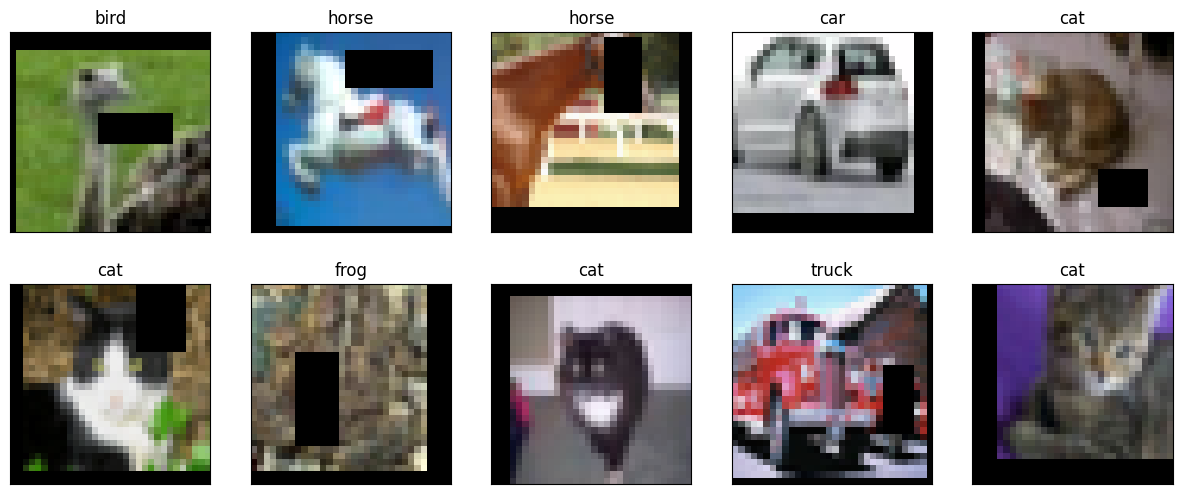

In [ ]:
def imshow(img):
    # Convert Tensor → numpy
    img = img.numpy()

    # Convert (C, H, W) → (H, W, C)
    img = np.transpose(img, (1, 2, 0))

    # De-normalize
    mean = np.array(cifar10_mean)
    std = np.array(cifar10_std)
    img = std * img + mean

    # Clamp về [0,1]
    img = np.clip(img, 0, 1)

    # Hiển thị ảnh
    plt.imshow(img)

# Lấy ngẫu nhiên 1 batch
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Chọn ngẫu nhiên 10 ảnh
indices = torch.randperm(images.size(0))[:10]
images_to_show = images[indices]
labels_to_show = labels[indices]

# Vẽ ảnh
fig = plt.figure(figsize=(15, 6))
for i in range(10):
    ax = fig.add_subplot(2, 5, i+1, xticks=[], yticks=[])
    imshow(images_to_show[i])
    ax.set_title(classes[labels_to_show[i]])

plt.show()

# CNN MODEL DEFINITION

## Architecture

| Stage   | Operation | Output Size |
|---------|-----------|------------|
| Input   | RGB Image | 3 × 32 × 32 |
| Conv1   | 3×3, 3→16 → BN → ReLU → MaxPool | 16 × 16 × 16 |
| Conv2   | 3×3, 16→32 → BN → ReLU → MaxPool | 32 × 8 × 8 |
| Conv3   | 3×3, 32→32 → BN → ReLU → MaxPool | 32 × 4 × 4 |
| Flatten | - | 512 |
| FC1     | 512 → 64 | 64 |
| FC2     | 64 → 10 | 10 |

---

## Hardware Resource

- Board: DE10-Standard (Cyclone V)
- On-chip memory: ≈ 5.761 Kbits ≈ 5.76 Mb ≈ **720 KB**

---

## Parameter Calculation

### Công thức:

- Params = K × K × Cin × Cout (+ bias)


### Chi tiết từng layer

| Layer | Weight | Bias | Total Params |
|------|--------|------|-------------|
| Conv1 (3→16) | 3×3×3×16 = 432 | 16 | 448 |
| Conv2 (16→32) | 3×3×16×32 = 4,608 | 32 | 4,640 |
| Conv3 (32→32) | 3×3×32×32 = 9,216 | 32 | 9,248 |
| FC1 (512→64) | 512×64 = 32,768 | 64 | 32,832 |
| FC2 (64→10) | 64×10 = 640 | 10 | 650 |


### Tổng Parameters

| Thành phần | Giá trị |
|----------|--------|
| Weights | 47,664 |
| Bias | 154 |


## Memory cho Parameters

| Thành phần | Cách tính | Dung lượng |
|----------|----------|-----------|
| Weights (INT8) | 47,664 × 1 byte | ~46.5 KB |
| Bias (INT32) | 154 × 4 byte | ~0.6 KB |
| **Total** | | **~47 KB** |

---

## Activation (Feature Map)

### Công thức:

- Activation = C × H × W


### Activation từng layer

| Layer | Size | Memory |
|------|------|--------|
| Input | 3×32×32 | ~3 KB |
| Conv1 | 16×32×32 | ~16 KB |
| Pool1 | 16×16×16 | ~4 KB |
| Conv2 | 32×16×16 | ~8 KB |
| Pool2 | 32×8×8 | ~2 KB |
| Conv3 | 32×8×8 | ~2 KB |
| Pool3 | 32×4×4 | ~0.5 KB |


### Worst-case (Double Buffer)

| Thành phần | Giá trị |
|----------|--------|
| Largest feature map | 16 KB |
| Double buffer | **~32 KB** |

---

## Buffer

### Chi tiết buffer

| Buffer Type | Công thức | Giá trị |
|------------|----------|--------|
| Line Buffer | K × W × Cin | ~1 KB |
| Double Buffer | 2 × C × H × W | ~32 KB |
| Partial Sum | Cout × W × 4 byte | ~2 KB |

---

## Tổng Memory Usage

| Thành phần | Dung lượng |
|----------|----------|
| Params | ~47 KB |
| Activation | ~32 KB |
| Buffer | ~10 KB |
| **TOTAL** | **~89 KB** |

---

## Kết luận

- Tổng sử dụng: **~89 KB**
- So với FPGA: **720 KB**


In [ ]:
class SimpleCNN(nn.Module):
  def __init__(self):
    super(SimpleCNN, self).__init__()
    # ===== Convolutional Backbone =====
    # Conv Block 1: 3 → 16 channels
    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
    self.bn1 = nn.BatchNorm2d(32)

    # Conv Block 2: 16 → 32 channels
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1, bias=False)
    self.bn2 = nn.BatchNorm2d(64)

    # Conv Block 3: 32 → 32 channels
    self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False)
    self.bn3 = nn.BatchNorm2d(64)

    # MaxPooling 2x2
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    # Feature map size
    self.flatten_size = 64 * 4 * 4  # 512

    self.fc1 = nn.Linear(self.flatten_size, 128)
    self.fc2 = nn.Linear(128, 10)

    # Weight initialization
    self._initialize_weights()

  def _initialize_weights(self):
    """Khởi tạo weights theo He initialization."""
    for m in self.modules():
      if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
      elif isinstance(m, nn.BatchNorm2d):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)
      elif isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        nn.init.zeros_(m.bias)

  def forward(self, x):
    # Conv Block 1: (B, 3, 32, 32) → (B, 16, 16, 16)
    x = self.pool(F.relu(self.bn1(self.conv1(x))))

    # Conv Block 2: (B, 16, 16, 16) → (B, 32, 8, 8)
    x = self.pool(F.relu(self.bn2(self.conv2(x))))

    # Conv Block 3: (B, 32, 8, 8) → (B, 32, 4, 4)
    x = self.pool(F.relu(self.bn3(self.conv3(x))))

    # Flatten: (B, 32, 4, 4) → (B, 512)
    x = x.view(x.size(0), -1)

    # FC1: (B, 512) → (B, 64)
    x = F.relu(self.fc1(x))

    # FC2: (B, 64) → (B, 10)
    x = self.fc2(x)

    return x

**TRAINING SETUP**
===============================================================================
- Khởi tạo device (GPU/CPU)
- Loss function, optimizer, scheduler

In [ ]:
epochs = 100

# Chọn device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n[Device] {device}")
if device.type == "cuda":
  print(f"  GPU: {torch.cuda.get_device_name(0)}")

# Khởi tạo model
model = SimpleCNN().to(device)

weights = torch.tensor([
    1.0,  # plane
    1.0,  # car
    1.3,  # bird
    1.6,  # cat
    1.1,  # deer
    1.3,  # dog
    1.0,  # frog
    1.0,  # horse
    1.0,  # ship
    1.0   # truck
]).to(device)

# Loss function
criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.05)

# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=5e-4,)

# Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,
                                                 T_max=epochs,
                                                 eta_min=1e-6,)


[Device] cuda
  GPU: Tesla T4


**TRAINING LOOP**
===============================================================================
- Huấn luyện model
- Validate mỗi epoch
- Lưu best model

In [ ]:
best_val_acc = 0.0
best_epoch = 0

for epoch in range(1, epochs+1):
    # ===== TRAIN =====
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Reset gradient
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # Loss
        loss = criterion(outputs, labels)

        # Backward
        loss.backward()

        # Update
        optimizer.step()

        # Tổng Loss
        running_loss += loss.item() * images.size(0)
        # Kết quả dự đoán
        _, predicted = outputs.max(1)
        # Tổng sample
        total += labels.size(0)
        # Tổng dự đoán đúng
        correct += predicted.eq(labels).sum().item()

    # Average Loss trên toàn dataset
    train_loss = running_loss / total
    # Accuracy trên toàn dataset
    train_acc = 100. * correct / total

    # ===== VALIDATE =====
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
         for images, labels in test_loader:
             images = images.to(device, non_blocking=True)
             labels = labels.to(device, non_blocking=True)

             # Forward
             outputs = model(images)

             # Loss
             loss = criterion(outputs, labels)

             # Tổng Loss
             running_loss += loss.item() * images.size(0)
             # Kết quả dự đoán
             _, predicted = outputs.max(1)
             # Tổng sample
             total += labels.size(0)
             # Tổng dự đoán đúng
             correct += predicted.eq(labels).sum().item()

    # Average Loss trên toàn dataset
    val_loss = running_loss / total
    # Accuracy trên toàn dataset
    val_acc = 100. * correct / total

    scheduler.step()

    # ===== SAVE BEST MODEL =====
    if val_acc > best_val_acc:
       best_val_acc = val_acc
       best_epoch = epoch
       torch.save({'epoch': epoch,
                   'model_state_dict': model.state_dict(),
                   'optimizer_state_dict': optimizer.state_dict(),
                   'val_acc': val_acc,
                   'val_loss': val_loss,
                   'train_acc': train_acc,
                   'train_loss': train_loss}, "/content/drive/MyDrive/Colab/best_model.pth")

    print(f"Epoch {epoch:3d}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}% | "
          f"Best Validation Accuracy: {best_val_acc:.2f}% (Epoch {best_epoch}/{epochs}) \n")

Epoch   1/100 | Train Loss: 2.7350, Acc: 27.16% | Val Loss: 1.8229, Acc: 40.20% | Best Validation Accuracy: 40.20% (Epoch 1/100) 

Epoch   2/100 | Train Loss: 1.8183, Acc: 36.78% | Val Loss: 1.6715, Acc: 44.21% | Best Validation Accuracy: 44.21% (Epoch 2/100) 

Epoch   3/100 | Train Loss: 1.6699, Acc: 42.91% | Val Loss: 1.5406, Acc: 49.69% | Best Validation Accuracy: 49.69% (Epoch 3/100) 

Epoch   4/100 | Train Loss: 1.5610, Acc: 47.83% | Val Loss: 1.4318, Acc: 53.95% | Best Validation Accuracy: 53.95% (Epoch 4/100) 

Epoch   5/100 | Train Loss: 1.4646, Acc: 52.06% | Val Loss: 1.3224, Acc: 58.90% | Best Validation Accuracy: 58.90% (Epoch 5/100) 

Epoch   6/100 | Train Loss: 1.3877, Acc: 55.40% | Val Loss: 1.3094, Acc: 59.37% | Best Validation Accuracy: 59.37% (Epoch 6/100) 

Epoch   7/100 | Train Loss: 1.3285, Acc: 58.11% | Val Loss: 1.2429, Acc: 62.56% | Best Validation Accuracy: 62.56% (Epoch 7/100) 

Epoch   8/100 | Train Loss: 1.2835, Acc: 60.10% | Val Loss: 1.1994, Acc: 63.85% | B

**LOAD BEST MODEL & GLOBAL TEST EVALUATION**
===============================================================================
- Load model tốt nhất đã lưu trong quá trình training
- Chuyển model sang chế độ inference
- Đánh giá trên toàn bộ test set
- Tính toán:
    + Test Loss
    + Test Accuracy

Hardware Note:
- Đây là kết quả inference (giống behavior khi deploy lên NPU)
- Không có gradient → tương đương chế độ chạy phần cứng

In [ ]:
# ===== LOAD BEST MODEL =====
# Load checkpoint từ file
checkpoint = torch.load("/content/drive/MyDrive/Colab/best_model.pth", map_location=device)

# Load trọng số vào model
model.load_state_dict(checkpoint['model_state_dict'])

# Lấy thông tin tốt nhất
best_epoch = checkpoint['epoch']
best_val_acc = checkpoint['val_acc']

# Đưa model lên device
model.to(device)
model.eval()

# ===== VALIDATE =====
running_loss = 0.0
correct = 0
total = 0

# Không tính gradient
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        # Cộng dồn loss theo batch size
        running_loss += loss.item() * images.size(0)
        # Lấy class có xác suất cao nhất
        _, predicted = outputs.max(1)
        # Tổng sample
        total += labels.size(0)
        # Cập nhật số dự đoán đúng
        correct += predicted.eq(labels).sum().item()

test_loss = running_loss / total
test_acc = 100. * correct / total

# ===== IN KẾT QUẢ =====
print("===== BEST MODEL EVALUATION =====")
print(f"Best Epoch           : {best_epoch}")
print(f"Best Val Accuracy    : {best_val_acc:.2f}%")
print(f"Test Accuracy        : {test_acc:.2f}%")
print(f"Test Loss            : {test_loss:.4f}")

===== BEST MODEL EVALUATION =====
Best Epoch           : 89
Best Val Accuracy    : 83.09%
Test Accuracy        : 83.09%
Test Loss            : 0.7674


**PER-CLASS ACCURACY ANALYSIS**
===============================================================================
- Đánh giá độ chính xác trên từng class riêng biệt
- Giúp phân tích model học tốt / kém ở class nào

Ý nghĩa:
- Quan trọng khi deploy NPU:
    + Biết class nào dễ bị sai → cần optimize thêm
- Phát hiện bias trong model

Output:
- Accuracy từng class (10 classes CIFAR-10)

In [ ]:
model.eval()
# Số lượng dự đoán đúng cho từng class
class_correct = [0 for _ in range(10)]
# Tổng số mẫu của từng class
class_total = [0 for _ in range(10)]

with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device, non_blocking=True)
    labels = labels.to(device, non_blocking=True)

    outputs = model(images)

    _, predicted = outputs.max(1)

    for i in range(labels.size(0)):
      label = labels[i].item()
      class_correct[label] += (predicted[i] == label).item()
      class_total[label] += 1

print(f"Using model from epoch {best_epoch} with val acc {best_val_acc:.2f}%")
print("\n===== PER-CLASS ACCURACY =====")
for i in range(10):
  acc = 100. * class_correct[i] / class_total[i]
  print(f"{classes[i]:>12s}: {acc:.1f}% ({class_correct[i]}/{class_total[i]})")

Using model from epoch 89 with val acc 83.09%

===== PER-CLASS ACCURACY =====
       plane: 83.9% (839/1000)
         car: 91.8% (918/1000)
        bird: 78.8% (788/1000)
         cat: 70.9% (709/1000)
        deer: 79.7% (797/1000)
         dog: 77.0% (770/1000)
        frog: 86.8% (868/1000)
       horse: 83.7% (837/1000)
        ship: 89.4% (894/1000)
       truck: 88.9% (889/1000)
